# Notebook 04 — Visualização e Análise dos Resultados

**Objetivo:** Gerar os gráficos e análises que compõem a seção de **Resultados e Discussões** do TCC.

Este notebook parte dos artefatos gerados pelo notebook 03:
- `results/resultados.csv` — métricas dos 8 experimentos
- `models/*.pkl` — modelos e vetorizadores treinados

**Visualizações geradas:**
1. Gráfico de barras comparativo de F1-Score (todos os experimentos)
2. Matriz de confusão do melhor modelo (Regressão Logística + TF-IDF)

In [12]:
# ===== SETUP: montar o Drive =====
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/tcc-sentiment-analysis/'
MODELS_PATH = DRIVE_PATH + 'models/'
RESULTS_PATH = DRIVE_PATH + 'results/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Importações

In [2]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

## 2. Gráfico Comparativo de F1-Score

O gráfico de barras abaixo compara o **F1-Score** de todos os 8 experimentos, agrupados por modelo e coloridos por vetorização (TF-IDF vs BoW).

O eixo Y começa em 0.80 para facilitar a visualização das diferenças entre os modelos.

In [3]:
# Carregar a tabela de resultados gerada pelo notebook 03
df_r = pd.read_csv(RESULTS_PATH + 'resultados.csv')

# Gráfico de barras: F1-Score por Modelo e Vetorização
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_r,
    x='Modelo',
    y='F1-Score',
    hue='Vetorização',
    palette='Blues'
)
plt.title('Comparação de F1-Score por Modelo e Vetorização')
plt.ylim(0.8, 1.0)  # foco na faixa relevante de desempenho
plt.tight_layout()

# Salvar para uso no TCC
plt.savefig(RESULTS_PATH + 'comparacao_f1.png', dpi=150)
plt.show()

## 3. Análise dos Resultados

O melhor modelo foi **Regressão Logística + TF-IDF** (F1 ≈ 0.889).

**Principais observações:**

- **TF-IDF superou BoW em todos os 4 modelos.** O TF-IDF penaliza palavras que aparecem em muitas reviews (como "film" e "movie"), dando mais peso às palavras verdadeiramente discriminativas para o sentimento.

- **Modelos lineares (Regressão Logística e SVM) se beneficiam mais do TF-IDF.** Ambos exploram diretamente a ponderação das features, ao contrário do Random Forest que opera com divisões binárias.

- **Random Forest apresentou menor variação entre vetorizações.** Árvores de decisão não utilizam magnitudes das features — apenas sua ordenação relativa — o que explica a insensibilidade à ponderação do TF-IDF.

- **Naive Bayes teve desempenho intermediário**, consistente com a literatura. Embora seja o modelo mais simples, ainda alcançou F1 ≈ 0.85 com TF-IDF.

## 4. Matriz de Confusão — Melhor Modelo

A matriz de confusão permite analisar em detalhe os acertos e erros do melhor modelo:
- **Verdadeiros Positivos (VP):** reviews positivos classificados corretamente
- **Verdadeiros Negativos (VN):** reviews negativos classificados corretamente  
- **Falsos Positivos (FP):** reviews negativos classificados erroneamente como positivos
- **Falsos Negativos (FN):** reviews positivos classificados erroneamente como negativos

> **Importante:** O `random_state=42` e `stratify=y` abaixo devem ser **idênticos** aos usados no notebook 03, para garantir que o conjunto de teste seja o mesmo.

In [7]:
# Recriar o conjunto de teste com os mesmos parâmetros do notebook 03
# (random_state e stratify DEVEM ser idênticos ao notebook 03)
df = pd.read_csv(DRIVE_PATH + 'data/imdb_clean.csv')
df['label'] = (df['sentiment'] == 'positive').astype(int)
X = df['review_clean']
y = df['label']

_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,  # DEVE ser igual ao notebook 03
    stratify=y        # DEVE ser igual ao notebook 03
)

# Carregar o melhor modelo e seu vetorizador correspondente
modelo = joblib.load(MODELS_PATH + 'Regressao_Logistica_TF-IDF.pkl')
vectorizer = joblib.load(MODELS_PATH + 'vectorizer_TF-IDF.pkl')

# Vetorizar o conjunto de teste com o MESMO vetorizador do treino
X_test_vec = vectorizer.transform(X_test)

# Gerar predições
y_pred = modelo.predict(X_test_vec)

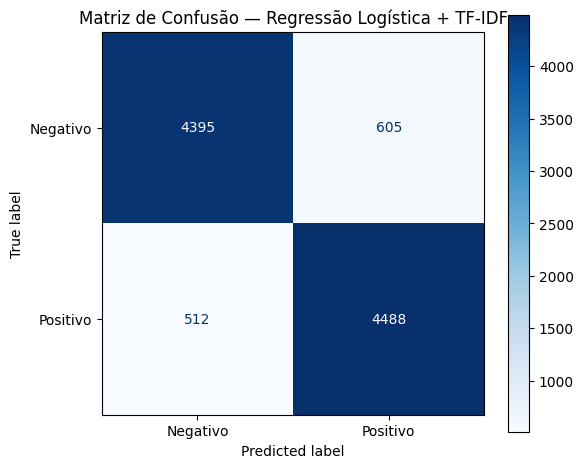

In [9]:
# Plotar a matriz de confusão do melhor modelo
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Negativo', 'Positivo'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusão — Regressão Logística + TF-IDF')
plt.tight_layout()

# Salvar para uso no TCC
plt.savefig(RESULTS_PATH + 'matriz_confusao.png', dpi=150)
plt.show()

---
## Conclusões Finais

- **Melhor modelo:** Regressão Logística + TF-IDF (F1 ≈ 0.889)
- **TF-IDF** superou Bag of Words em todos os experimentos
- A **Matriz de Confusão** mostra distribuição equilibrada de erros entre FP e FN, sem viés para uma classe
- Todos os gráficos foram salvos na pasta `results/` para uso direto no TCC

**Próximo passo:** `app.py` — interface Streamlit para demonstração interativa dos modelos